In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/teams.csv")

df.head()

,year,lgID,tmID,franchID,confID,divID,rank,playoff,seeded,firstRound,...,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,arena
0,9,WNBA,ATL,ATL,EA,NaN,7,N,0,NaN,...,34,1,16,3,14,2,18,6825,141379,Philips Arena
1,10,WNBA,ATL,ATL,EA,NaN,2,Y,0,L,...,34,12,5,6,11,10,12,6950,120737,Philips Arena
2,1,WNBA,CHA,CHA,EA,NaN,8,N,0,NaN,...,32,5,11,3,13,5,16,6475,90963,Charlotte Coliseum
3,2,WNBA,CHA,CHA,EA,NaN,4,Y,0,W,...,32,11,5,7,9,15,6,6500,105525,Charlotte Coliseum
4,3,WNBA,CHA,CHA,EA,NaN,2,Y,0,L,...,32,11,5,7,9,12,9,6450,106670,Charlotte Coliseum


In [ ]:
# Calculate win percentage
df["win_pct"] = df["won"] / (df["won"] + df["lost"])

# Calculate offensive field goal percentage
df["fg_pct"] = df["o_fgm"] / (df["o_fgm"] + df["o_fga"])

# Calculate 3 points made percentage
df["3p_pct"] = df["o_3pm"] / (df["o_3pm"] + df["o_3pa"])

# Calculate point average (made points vs allowed points)
df["pa_pct"] = df["o_pts"] / (df["o_pts"] + df["d_pts"])

#
df["ft_pct"] = df["o_ftm"] / (df["o_ftm"] + df["o_fta"])

#FIND MORE FEATURES!

feature_cols = ["win_pct", "fg_pct", "3p_pct", "pa_pct"]

df[feature_cols].head()

print(df.head())

   year  lgID tmID franchID confID  divID  rank playoff  seeded firstRound  \
0     9  WNBA  ATL      ATL     EA    NaN     7       N       0        NaN   
1    10  WNBA  ATL      ATL     EA    NaN     2       Y       0          L   
2     1  WNBA  CHA      CHA     EA    NaN     8       N       0        NaN   
3     2  WNBA  CHA      CHA     EA    NaN     4       Y       0          W   
4     3  WNBA  CHA      CHA     EA    NaN     2       Y       0          L   

   ... awayL confW confL   min  attend               arena   win_pct  \
0  ...    14     2    18  6825  141379       Philips Arena  0.117647   
1  ...    11    10    12  6950  120737       Philips Arena  0.529412   
2  ...    13     5    16  6475   90963  Charlotte Coliseum  0.250000   
3  ...     9    15     6  6500  105525  Charlotte Coliseum  0.562500   
4  ...     9    12     9  6450  106670  Charlotte Coliseum  0.562500   

     fg_pct    3p_pct    pa_pct  
0  0.283857  0.252500  0.468132  
1  0.309639  0.233607  0.50565

In [41]:
CORR_THRESHOLD = 0.2


corr = df[["rank"] + feature_cols].corr()

# Filter out all features with low correlation given the correlation threshold
strong_corr = corr["rank"][corr["rank"].abs() >= CORR_THRESHOLD]

strong_corr.sort_values()


win_pct   -0.887239
pa_pct    -0.811704
fg_pct    -0.529524
3p_pct    -0.284543
rank       1.000000
Name: rank, dtype: float64

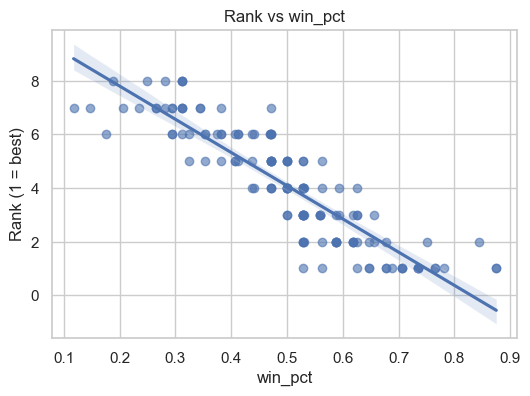

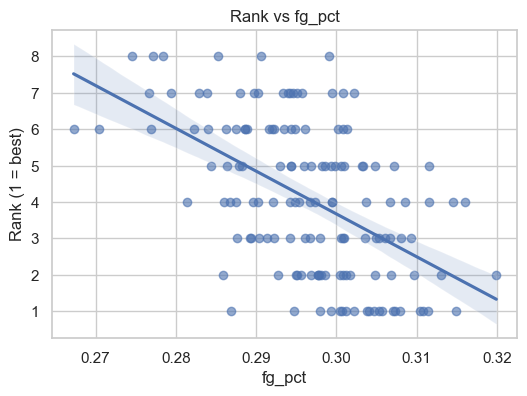

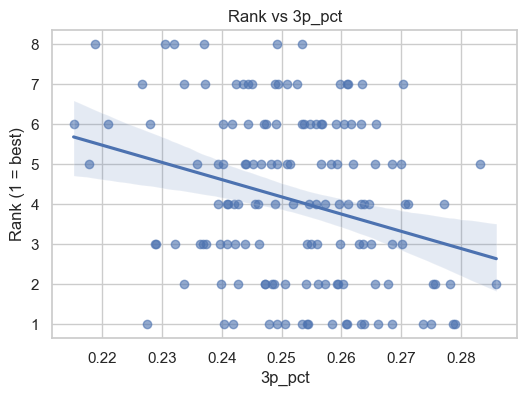

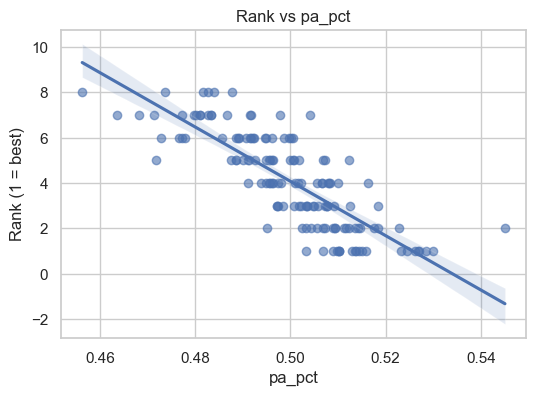

In [42]:
# Set style
sns.set(style="whitegrid", context="notebook")

for col in strong_corr.index:
    if col == "rank":
        continue
    
    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y="rank", data=df, scatter_kws={"alpha":0.6})
    plt.title(f"Rank vs {col}")
    plt.xlabel(col)
    plt.ylabel("Rank (1 = best)")
    plt.show()


In [45]:
# Train model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Dataframe of predictors
x = df[feature_cols]

# Target variable
y = df["rank"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")






Mean squared error: 0.9432
Root mean squared error: 0.9712
